# TUTORIAL: Introduction to ensemble data assimilation
<script src='https://cdnjs.cloudflare.com/ajax/libs/mathjax/2.7.4/MathJax.js?config=default'></script>

* [Why ensembles?](#why)
* [State estimation with the ensemble Kalman filter](#fifth)
* [Test case: twin experiment on a Van der Pol oscillator](#fifth-vdp)
    * [What is a twin experiment?](#fifth-twin)
    * [The Van der Pol system](#vdp)
* [EnKF vs. KF: Monte Carlo convergence](#enkf)
* [Where next?](#next)


# 1. Why ensembles? <a name="why"></a>

[Tutorial 10](10_real-time-DA_intro.ipynb) closed with the classical Kalman filter — the exact Bayesian filter in the linear-Gaussian setting. Its covariance recursion, however, relies on three things that real applications rarely offer:

1. **Linear dynamics.** For a nonlinear model the forecast pdf does not stay Gaussian, and no closed recursion on (mean, covariance) exists. The extended KF linearizes $\mathbf{F}_\mathrm{jac} = \partial\mathcal{F}/\partial\boldsymbol{\psi}$ locally, but degrades — and fails — for strongly nonlinear or chaotic dynamics.
2. **A tangent-linear model.** Even when linearization is acceptable, the Jacobian of a legacy or black-box solver is often simply not available.
3. **The full covariance.** $\mathbf{C}_{\psi\psi}$ is $N \times N$; storing and propagating it is hopeless for the $N \sim 10^6$–$10^9$ states of weather or CFD models.

**Stochastic ensemble methods** sidestep all three at once: the covariance is estimated from the sample statistics of $m \ll N$ ensemble members, each propagated by the *nonlinear* model itself — the model is only ever run, never differentiated. The price is a sampling error that decays as $m^{-1/2}$, which we quantify in the [last section](#enkf).



<br /> 


# 2. State estimation with the ensemble Kalman filter <a class="anchor" id="fifth"></a>

Under the Gaussian assumption, the inverse problem of finding the states, $\boldsymbol{\phi}$, given some observations, $\mathbf{d}$, would be solved by the Kalman filter equations if the model dynamics were linear. **Stochastic ensemble data assimilation** methods can be used for nonlinear dynamics because they do not require to propagate the covariance, in contrast to other sequential methods, e.g., the extended Kalman filter.  Stochastic ensemble filters track in time $m$-realizations of the augmented state to estimate the mean and covariance of the prior pdf. 

Ensemble methods estimate the first two moments as
$$
\begin{align}
	 \mathbb{E}(\boldsymbol{\phi})\approx\bar{\boldsymbol{\phi}}=\dfrac{1}{m}\sum^m_{j=1}{\boldsymbol{\phi}_j} 
	  \quad \text{and} \quad
	 \mathbf{C}_{\phi\phi} 
			\approx\dfrac{1}{m-1}\sum^m_{j=1}(\boldsymbol{\phi}_i-\bar{\boldsymbol{\phi}})\otimes(\boldsymbol{\phi}_i-\bar{\boldsymbol{\phi}}). 
\end{align}
$$
Each ensemble member $j$ is forecast independently in time with $\mathcal{F}(\boldsymbol{\phi}_j)$ to obtain an ensemble of forecast states $\boldsymbol{\phi}_j^\text{f}$. When a sensor provides noisy data $\mathbf{d}$,  real-time data assimilation statistically combines the noisy data and the forecast ensemble to improve our knowledge in the system's parameters and states (i.e., to compute an analysis ensemble $\boldsymbol{\phi}_j^\mathrm{a}$). Mathematically, we aim to minimize the cost function
$$
\begin{align}
\mathcal{J}(\boldsymbol{\phi}_j) = &\left\|\boldsymbol{\phi}_j-\boldsymbol{\phi}_j^\mathrm{f}\right\|^2_{\mathbf{C}^{\mathrm{f}^{-1}}_{\phi\phi}} +
 \left\|{\mathbf{M}\boldsymbol{\phi}}_j-\boldsymbol{d}_j\right\|^2_{\mathbf{C}^{-1}_{dd}}, \quad \mathrm{for} \quad j=0,\dots,m-1,
\end{align}
$$
where $\left\|\cdot\right\|^2_{\mathbf{C}^{-1}}$ is the L2-norm weighted by the semi-positive definite matrix $\mathbf{C}^{-1}$. The ensemble Kalman filter (EnKF) minimizes the cost function to obtain an analysis ensemble $\boldsymbol{\phi}_j^\mathrm{a}$ from the forecast ensemble $ \boldsymbol{\phi}_j^\mathrm{f}$ and the observations $\mathbf{d}$ as
$$
\begin{align}
    \boldsymbol{\phi}_j^\mathrm{a} 
    &= \boldsymbol{\phi}_j^\mathrm{f}+\mathbf{K}\left[\mathbf{d}_j - \mathbf{M}\boldsymbol{\phi}_j^\mathrm{f}\right], \quad j=0,\dots,m-1,
\end{align}
$$
where $\mathbf{K}=\mathbf{C}_{\phi\phi}^\mathrm{f}\mathbf{M}^\mathrm{T}\left(\mathbf{C}_{dd}+\mathbf{M}\mathbf{C}_{\phi\phi}^\mathrm{f}\mathbf{M}^\mathrm{T}\right)^{-1}$ is the Kalman gain matrix.  
 
</p>

<br />





<br />

___

#### Exercises
<em><font color=#7CB9E8> Derive the EnKF from the cost function $\mathcal{J}(\phi)$. Start from a univariate case.  For Nphi > 1, the derivation requires the Woodbury matrix inversion. 
<em><font color=#7CB9E8> Show that this implementation of the EnKF is equivalent to the equations above, but it avoids storing the full covariance matrix. 
___



In [1]:
import numpy as np
from scipy import linalg
import matplotlib.pyplot as plt


In [2]:

def EnKF_analysis(Af, observations, C_dd, M):
    """ 
        Inputs:
            case: ensemble forecast as a class object
            observations: observation at time t
            C_dd: observation error covariance matrix
        Returns:
            Aa: analysis ensemble 
    """
    psi_f_m = np.mean(Af, axis=1, keepdims=True)     # ensemble mean
    Psi_f = Af - psi_f_m                        # deviations from the mean
    
    # Create an ensemble of observations
    m = Af.shape[-1]
    D = rng.multivariate_normal(observations, C_dd, m).transpose()
    
    # Mapped forecast matrix M(Af) and mapped deviations M(Af')
    Y = np.dot(M, Af)
    S = np.dot(M, Psi_f)
    
    C = (m - 1) * C_dd + np.dot(S, S.T)  # Kalman gain matrix
    X = np.dot(S.T, np.dot(linalg.inv(C), (D - Y)))

    return Af + np.dot(Af, X)


<br />

# 3. Test case: twin experiment on the Van der Pol oscillator <a class="anchor" id="fifth-vdp"></a>


## 3.1 What is a twin experiment? <a class="anchor" id="fifth-twin"></a>

In real scenarios, we do not have access to the truth, thus we do not know which are the optimal state and parameters which represent the physical system. To analyse the EnKF we take a twin experiment approach, which consist of generating a synthetic true state from the same numerical model as the forecast. The observations are then created by adding stochastic noise to the synthetic truth, which mimics the sampling in a real experiment. 

The steps in a twin experiment are:
1. We compute the truth $\mathbf{d}^\dagger$ as 
$$
\begin{equation}
\left\{
\begin{array}{rcl}
\mathrm{d}\boldsymbol{\phi^\dagger } &=& \mathbf{F}\left(\boldsymbol{\phi}^\dagger\right){\mathrm{d} t}  \\
\mathbf{d}^\dagger &=& \mathbf{M}\boldsymbol{\phi}^\dagger
\end{array}
\right.
\end{equation}
$$
where $\boldsymbol{\phi^\dagger }$ is the true state to infer.  We assume that $\boldsymbol{\phi^\dagger }$ are unknown from now on.  

2. Sample observations from the truth as  $\mathbf{d} = \mathbf{d}^\dagger +  \boldsymbol{\epsilon}_d$.

3. Initialise an ensemble of simulations $\boldsymbol{\phi}_j$.  

4. Perform data assimilation with the EnKF.


## 3.2 The Van der Pol system <a class="anchor" id="vdp"></a>



The simplest form of a nonlinear oscillator is the Van der Pol model,  which is a forced oscillator with linear damping. The time evolution of the Van der Pol oscillator is governed by the second-order differential equation
\begin{align}
    \ddot{\eta} + \omega^2{\eta} =  \dot{q} - \zeta\dot{\eta}, 
\end{align}
where $\omega$ is the angular oscillating frequency, $\zeta$ is the damping coefficient, and $\dot{q}$ is a forcing term. One application of this system is thermoacoustic systems, in which  $\eta$ represents the acoustic velocity, and $\dot{q}$ is the heat release rate, which can be modelled as  
\begin{equation}
    \dot{q} = \beta\dot{\eta}\left(1 - \dfrac{\kappa\eta^2}{\beta + \kappa\eta^2}\right),
\end{equation}
 where $\kappa$ is the nonlinearity coefficient, and $\beta$ is the forcing strength. Using this heat release law, the Van der Pol oscillator can be written as the system of ordinary differential equations
\begin{equation}
\left\{
\begin{array}{rcl}
    \dfrac{\mathrm{d}\eta}{\mathrm{d} t} &=& \mu\\
    \dfrac{\mathrm{d}\mu}{\mathrm{d} t} &=& -\omega^2\eta + \mu \left(\beta - \zeta -\dfrac{\beta\kappa\eta^2}{\beta + {\kappa}\eta^2}\right).
\end{array}
\right.
\end{equation}
In state-space notation, the state vector is $\boldsymbol{\phi} = [\mu; \eta]$, and the model estimate (i.e., the measurable quantity) is only the acoustic velocity $\eta$.  


### 1) Create the truth

In [3]:

from romda.models.physical import VdP  # Import Van der Pol model
from romda.estimators import EnSRKF


rng = np.random.default_rng(0)


dt_t = 2e-4
true_params = dict(dt=dt_t,
                   psi0=rng.random(2),
                   Nq=1)

# Initialize model
true_case = VdP(**true_params)

# Forecast model
t_max = 2.5
psi, t = true_case.time_integrate(int(t_max / true_case.dt))
true_case.update_history(psi, t)

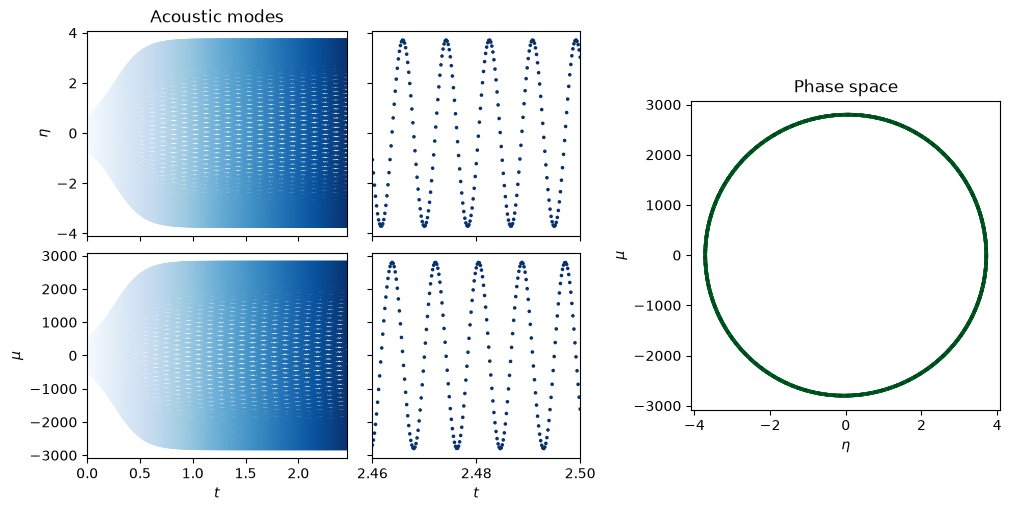

In [4]:

# Visualize model
fig1 = plt.figure(figsize=(10, 5), layout="constrained")
sub_fig1 = fig1.subfigures(1, 2, width_ratios=[1.5, 1])
axs = sub_fig1[0].subplots(2, 2, sharex='col', sharey='row', width_ratios=[1, 0.8])
Nt_zoom = int(true_case.t_CR / true_case.dt)
xlims = [[true_case.hist_t[0], true_case.hist_t[-1]-true_case.t_CR], [true_case.hist_t[-1]-true_case.t_CR, true_case.hist_t[-1]]]
for axs_, xl, tl in zip([axs[:, 0], axs[:, 1]], xlims, ['Acoustic modes', '']):
    for ii, ax, lbl in zip([0, 1], axs_, true_case.state_labels):
        ax.scatter(true_case.hist_t, true_case.hist[:, ii], c=true_case.hist_t, cmap='Blues', s=10, marker='.')
        if xl == xlims[0]:
            ax.set(ylabel=lbl)
    axs_[-1].set(xlabel='$t$', xlim=xl)
    axs_[0].set_title(tl)
ax = sub_fig1[1].subplots(1, 1)
ax.set_title('Phase space')
Nt_transient = int(true_case.t_transient // true_case.dt)
ax.scatter(true_case.hist[-Nt_transient:, 0], true_case.hist[-Nt_transient:, 1], c=true_case.hist_t[-Nt_transient:], cmap='Greens', s=10, marker='.')
ax.set(xlabel=true_case.state_labels[0], ylabel=true_case.state_labels[1])
ax.set_aspect(1. / ax.get_data_ratio())


### 2) Sample observations from the truth

...Adding noise: gauss, add with level 0.3.


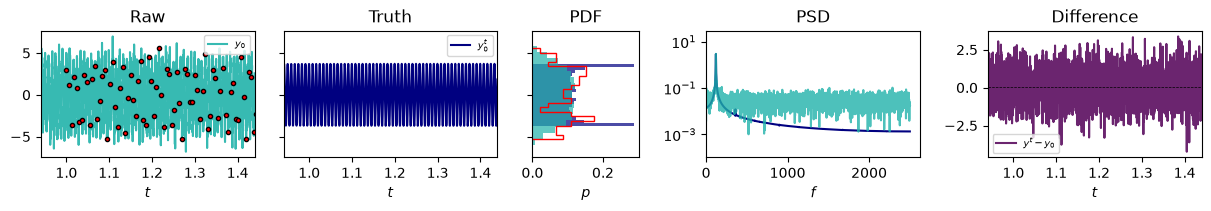

In [5]:
from romda.observations import Observations


truth = Observations(model=true_case, 
                    t_start=1.0, 
                    t_stop=1.5, 
                    Nt_obs=30, 
                    add_noise=True,
                    noise_type='gauss, add',
                    noise_level=0.3,
                    dt=dt_t
                    )

Observations.plot_truth(truth)

### 3) Create forecast ensemble

Any ensemble estimator of the repository can hold the ensemble (here `EnSRKF`); its built-in `analysis_step` implements the kernel derived above, but in this tutorial we apply `EnKF_analysis` by hand to see every step. Note that the ensemble state is *augmented* with the observables, $[\boldsymbol{\phi}; \mathbf{M}\boldsymbol{\phi}]$, so that the measurement operator `filter_ens.M` simply selects the observable rows.

In [6]:
from romda.estimators import EnSRKF

ensemble = EnSRKF(parent_model=VdP,      
                    dt=dt_t,             
                    m=10,               # Number of ensemble members
                    std_phi=1.,        # Initial uncertainty in the state
                    Nq = 1,             # Number of observed quantities
                    # psi0=np.array([2.5, 2000.]) # Initial condition for the ensemble mean
                    )


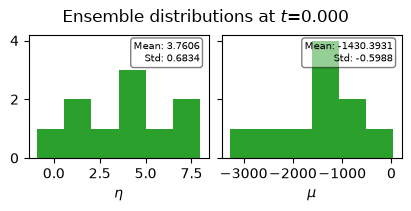

In [7]:
ensemble.visualize_state()

### 4) Apply data assimilation

In [8]:

rng = np.random.default_rng(0)

filter_ens = ensemble.copy()


# Define measurement error covariance matrix
std_d = 0.2 * np.max(abs(truth.y_obs), axis=0)  

Cdd = np.diag(std_d ** 2)

# Measurement operator on the augmented state [phi; q]: it selects the observable rows
M = filter_ens.M
print(f"M = {M}")

# ----------------------------------------------------------------------------
for d, t_d in zip(truth.y_obs, truth.t_obs):

    # Forecast step: propagate the ensemble to the observation time
    filter_ens.forecast_step(t_end=t_d)

    # Analysis step: augment the forecast ensemble with its observables and apply the EnKF kernel
    Af = np.vstack((filter_ens.current_state, filter_ens.model.get_observables()))
    Aa = EnKF_analysis(Af, d, Cdd, M)

    # The analysis state becomes the initial condition of the next forecast
    filter_ens.update_history(Aa[:filter_ens.Nphi], filter_ens.current_time, modify_saved_states=True)
    filter_ens.assimilated_data = (d, t_d)
# ----------------------------------------------------------------------------


# #Forecast the ensemble further without assimilation
# t_extra = filter_ens.model.hist_t[-1] + filter_ens.model.t_CR

# filter_ens.forecast_step(t_extra, averaged=True, close=True)

M = [[0. 0. 1.]]
Initializing multiprocessing pool for IVPIntegrator with m=10 and 10 pools.


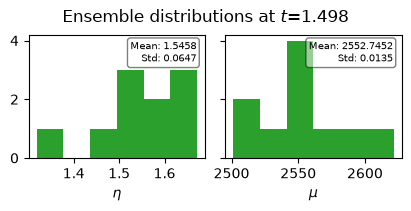

In [9]:
filter_ens.visualize_state(time_indices=[0, -1])

/storage0/anovoama/romda/src/estimators/ensembles.py:924: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  fig1.legend(loc='center', bbox_to_anchor=(0.5, 1.05), ncol=6, frameon=False)


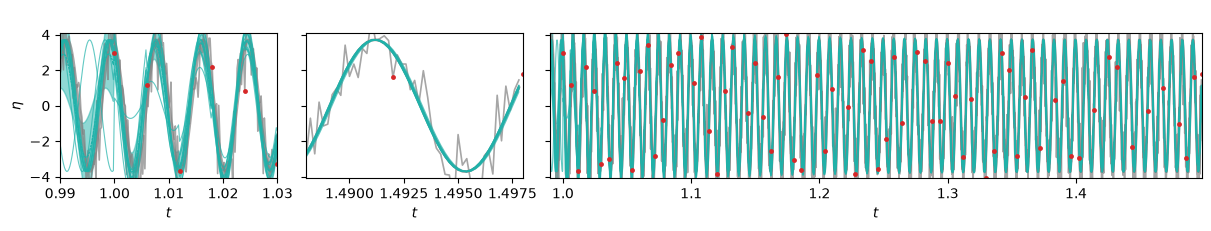

In [10]:
filter_ens.visualize_history(plot_members=True, truth=truth)




<br />

___


### Exercises


<em> 
    
<font color=#7CB9E8> In practice, particularly for high-dimensional systems, only sparse or partial observations are available.  How does observing only one state affect the solution? 

</em>

___

# 4. EnKF vs. KF: Monte Carlo convergence <a name="enkf"></a>

The hand-rolled EnKF above ran on a nonlinear model, where the exact posterior is unknown. To measure *how good* the ensemble approximation is, we return to the linear-Gaussian problem of [tutorial 10](10_real-time-DA_intro.ipynb) — the discrete damped oscillator — where the exact solution is given by the classical Kalman filter. On a linear-Gaussian problem, the stochastic (perturbed-observation) EnKF is a **Monte Carlo implementation of the Kalman filter**: as $m \to \infty$ its mean and covariance converge to the exact KF values, with a sampling error that decays as $m^{-1/2}$.

Note what the EnKF does *not* need: an `F_jac`. Each member is propagated through the model itself, so the forecast covariance — including the $x_0$–$x_1$ correlation that reconstructs the unobserved component — is carried by the ensemble. This is precisely the property that lets ensemble filters handle nonlinear models, where no exact covariance propagation exists.

This time we use the repository's estimators (`KalmanFilter` and `EnKF` from `romda.estimators`) instead of the hand-rolled function. To compare like with like, we give the EnKF the same Gaussian prior as the KF, by sampling the $m$ initial members from $\mathcal{N}(\boldsymbol{\psi}_0, \mathbf{C}_{\psi\psi,0})$ and passing them as a pre-built `ensemble_psi0` (the default in-model ensemble generation of `init_ensemble` assumes a transient run, which `LinearModel` does not have).


In [11]:
# The damped linear oscillator of tutorial 10, and its exact Kalman-filter solution
from romda.models.data_driven import LinearModel
from romda.estimators import KalmanFilter, EnKF

from romda.plotting import Palette   # one color per entity, shared by all romda figures
c_truth, c_obs, c_kf = Palette.TRUE, Palette.OBS, Palette.UNBIASED
c_enkf = {m: Palette.get_color('BIASED', a) for m, a in zip([5, 20, 100], [0.35, 0.65, 1.0])}

dt = 1.0
theta, r = 2 * np.pi / 40, 0.998
F = r * np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
M_obs = np.array([[1.0, 0.0]])    # observe only the first component
Nphi, Nq = F.shape[0], M_obs.shape[0]

lin_truth_model = LinearModel(F=F, M_obs=M_obs, psi0=np.array([3.0, 0.0]), dt=dt)
psi_lin, t_lin = lin_truth_model.time_integrate(Nt=128)
lin_truth_model.update_history(psi_lin, t_lin)
y_true = lin_truth_model.hist[:, :Nphi, 0] @ M_obs.T

lin_truth = Observations(y_true=y_true, t_true=lin_truth_model.hist_t,
                         t_start=4.0, t_stop=124.0, Nt_obs=10,
                         add_noise=True, noise_type='gauss, add', noise_level=0.1)
sigma_d = lin_truth.noise_level * np.max(np.abs(lin_truth.y_true[..., 0]), axis=0)
Cdd_lin = np.diag(sigma_d ** 2)

# Exact KF reference (see tutorial 10)
psi0_prior = np.array([2.0, 1.0])       # biased initial guess (the truth starts at [3, 0])
Cpp0 = 1.5 ** 2 * np.eye(Nphi)          # prior covariance at t = 0
kf = KalmanFilter(N=Nphi, Nq=Nq, Cdd=Cdd_lin, psi0=psi0_prior, Cpp0=Cpp0, M=M_obs,
                  model=LinearModel(F=F, M_obs=M_obs, psi0=psi0_prior, dt=dt))
sig_a, psi_a = [], []
for d_k, t_d in zip(lin_truth.y_obs, lin_truth.t_obs):
    kf.forecast_step(t_end=t_d)
    kf.analysis_step(d=d_k, Cdd=Cdd_lin)
    sig_a.append(np.sqrt(np.diag(kf.Cpp)))
    psi_a.append(kf.current_state.copy())
sig_a, psi_a = np.array(sig_a), np.array(psi_a)
t_kf, psi_kf = kf.model.hist_t, kf.model.hist[:, :, 0]


...Adding noise: gauss, add with level 0.1.


In [12]:
def run_enkf(m, seed=0):
    '''Stochastic EnKF on the same problem, with the same Gaussian prior and m members.'''
    lm = LinearModel(F=F, M_obs=M_obs, psi0=psi0_prior, dt=dt, seed=seed)
    ens0 = psi0_prior[:, None] + np.linalg.cholesky(Cpp0) @ lm.rng.standard_normal((Nphi, m))

    enkf = EnKF(parent_model=lm, m=m, ensemble_psi0=ens0)
    mean_a = []
    for d, t_d in zip(lin_truth.y_obs, lin_truth.t_obs):
        enkf.forecast_step(t_end=t_d)
        enkf.analysis_step(d=d, Cdd=Cdd_lin)
        mean_a.append(enkf.current_state.mean(axis=-1))
    return enkf, np.array(mean_a)


m_values = [5, 20, 100]
enkf_runs = {m: run_enkf(m) for m in m_values}

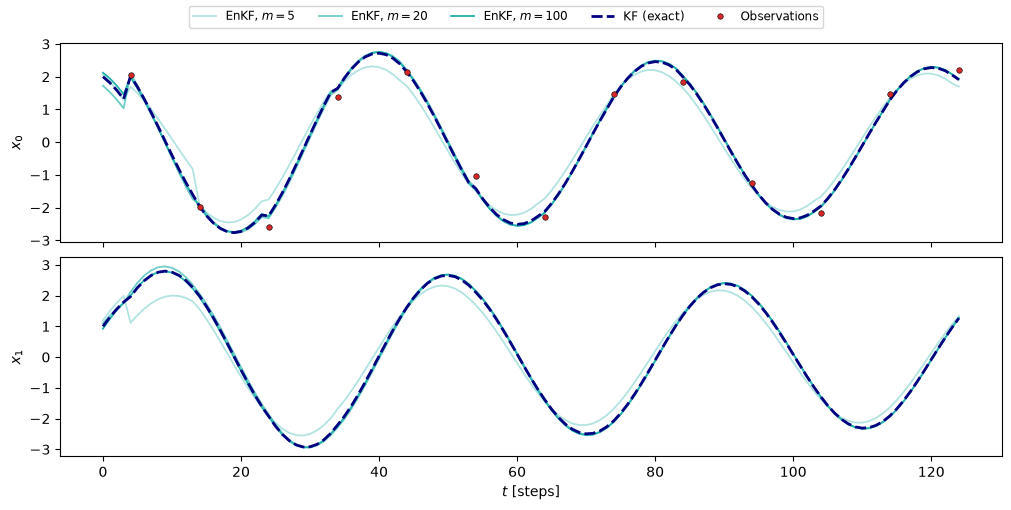

In [13]:
fig, axs = plt.subplots(2, 1, figsize=(10, 5), sharex=True, layout='constrained')
for ii, ax in enumerate(axs):
    for m in m_values:
        enkf, _ = enkf_runs[m]
        ax.plot(enkf.model.hist_t, enkf.model.hist[:, ii, :].mean(axis=-1),
                color=c_enkf[m], lw=1.3, label=f'EnKF, $m={m}$')
    ax.plot(t_kf, psi_kf[:, ii], color=c_kf, lw=2, dashes=(4, 1.5), label='KF (exact)')
    ax.set(ylabel=lin_truth_model.state_labels[ii])
axs[0].plot(lin_truth.t_obs, lin_truth.y_obs[:, 0], 'o', ms=4, color=c_obs, mec='k', mew=0.4, lw=0,
            label='Observations')
fig.legend(*axs[0].get_legend_handles_labels(), loc='outside upper center', fontsize='small', ncols=5)
axs[-1].set(xlabel='$t$ [steps]');

In [14]:
print(f"{'Final posterior spread':>22s}   sigma_x0   sigma_x1")
print(f"{'KF (exact)':>22s}   {sig_a[-1][0]:8.3f} {sig_a[-1][1]:10.3f}")
for m in m_values:
    s = enkf_runs[m][0].current_state.std(axis=-1, ddof=1)
    print(f"{f'EnKF m={m}':>22s}   {s[0]:8.3f} {s[1]:10.3f}")

Final posterior spread   sigma_x0   sigma_x1
            KF (exact)      0.100      0.108
              EnKF m=5      0.068      0.076
             EnKF m=20      0.092      0.105
            EnKF m=100      0.105      0.104


With $m=5$ the ensemble mean visibly wanders around the exact solution and the sample spread is a poor estimate of the true posterior $\sigma$; with $m=100$ the two are barely distinguishable. To quantify the convergence, we measure the RMS deviation of the EnKF analysis mean from the KF analysis mean over the assimilation window, averaged over several noise seeds. The stochastic EnKF is a Monte Carlo method, so the error should decay as $m^{-1/2}$.

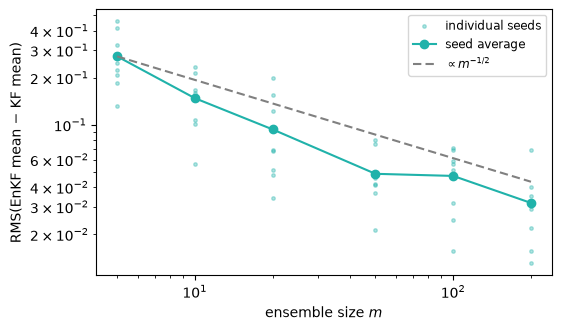

In [15]:
m_sweep = [5, 10, 20, 50, 100, 200]
n_seeds = 8

err = np.zeros((len(m_sweep), n_seeds))
for jj, m in enumerate(m_sweep):
    for seed in range(n_seeds):
        _, mean_a = run_enkf(m, seed=seed)
        err[jj, seed] = np.sqrt(np.mean((mean_a - psi_a) ** 2))

fig, ax = plt.subplots(figsize=(5.5, 3.2), layout='constrained')
ax.loglog(np.repeat(m_sweep, n_seeds), err.ravel(), '.', color=c_enkf[5], ms=5, label='individual seeds')
ax.loglog(m_sweep, err.mean(axis=1), 'o-', color=c_enkf[100], lw=1.5, label='seed average')
guide = err.mean(axis=1)[0] * np.sqrt(m_sweep[0] / np.asarray(m_sweep, dtype=float))
ax.loglog(m_sweep, guide, color=c_truth, dashes=(4, 2), label='$\\propto m^{-1/2}$')
ax.set(xlabel='ensemble size $m$', ylabel='RMS(EnKF mean $-$ KF mean)')
ax.legend(fontsize='small');

# 5. Where next? <a name="next"></a>


- [Tutorial 13](13_real-time-DA-augmented-state.ipynb) — we rarely have perfect knowledge of the model parameters: combined state and parameter estimation via the augmented state.
- [Tutorial 15](15_real-time-DA_Lorenz63.ipynb) — the chaotic case (Lorenz 63), where the ensemble approximation is the only practical option.

<br />

___

#### Exercise
<em><font color=#7CB9E8> Run the EnKF with $m = 2$. What happens to the sample covariance, and why?</font></em>

___
